In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.shape
df.info()
df.isnull().sum()
df['diabetes'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,count
diabetes,
0,91500
1,8500


In [5]:
df['gender'].value_counts()
df['smoking_history'].value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


In [6]:
print(df['gender'].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


In [7]:
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)
df.shape

(100000, 14)

In [8]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(df, train_size=15000, stratify=df['diabetes'], random_state=42)
df_sample['diabetes'].value_counts()

,count
diabetes,
0,13725
1,1275


In [10]:
X = df_sample.drop('diabetes', axis=1)
y = df_sample['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
X_train.shape
y_train.value_counts()

,count
diabetes,
0,10980
1,1020


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

0.9596666666666667
[[2714   31]
 [  90  165]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2745
           1       0.84      0.65      0.73       255

    accuracy                           0.96      3000
   macro avg       0.90      0.82      0.85      3000
weighted avg       0.96      0.96      0.96      3000



In [15]:
log_acc = accuracy_score(y_test, y_pred_log)
log_report = classification_report(y_test, y_pred_log, output_dict=True)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [17]:
print(accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)

0.954
[[2721   24]
 [ 114  141]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2745
           1       0.85      0.55      0.67       255

    accuracy                           0.95      3000
   macro avg       0.91      0.77      0.82      3000
weighted avg       0.95      0.95      0.95      3000



In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [19]:
print(accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)

0.9483333333333334
[[2658   87]
 [  68  187]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2745
           1       0.68      0.73      0.71       255

    accuracy                           0.95      3000
   macro avg       0.83      0.85      0.84      3000
weighted avg       0.95      0.95      0.95      3000



In [20]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [21]:
print(accuracy_score(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)

0.8673333333333333
[[2399  346]
 [  52  203]]
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      2745
           1       0.37      0.80      0.50       255

    accuracy                           0.87      3000
   macro avg       0.67      0.84      0.71      3000
weighted avg       0.93      0.87      0.89      3000



In [22]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [23]:
print(accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)

0.9596666666666667
[[2728   17]
 [ 104  151]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2745
           1       0.90      0.59      0.71       255

    accuracy                           0.96      3000
   macro avg       0.93      0.79      0.85      3000
weighted avg       0.96      0.96      0.96      3000



In [24]:
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Naive Bayes', 'SVM'],
    'Accuracy': [log_acc, knn_acc, dt_acc, nb_acc, svm_acc],
    'Precision (diabetes)': [log_report['1']['precision'], knn_report['1']['precision'], dt_report['1']['precision'], nb_report['1']['precision'], svm_report['1']['precision']],
    'Recall (diabetes)': [log_report['1']['recall'], knn_report['1']['recall'], dt_report['1']['recall'], nb_report['1']['recall'], svm_report['1']['recall']],
    'F1-score (diabetes)': [log_report['1']['f1-score'], knn_report['1']['f1-score'], dt_report['1']['f1-score'], nb_report['1']['f1-score'], svm_report['1']['f1-score']]
})
comparison_table

,Model,Accuracy,Precision (diabetes),Recall (diabetes),F1-score (diabetes)
0,Logistic Regression,0.959667,0.841837,0.647059,0.731707
1,KNN,0.954000,0.854545,0.552941,0.671429
2,Decision Tree,0.948333,0.682482,0.733333,0.706994
3,Naive Bayes,0.867333,0.369763,0.796078,0.504975
4,SVM,0.959667,0.898810,0.592157,0.713948


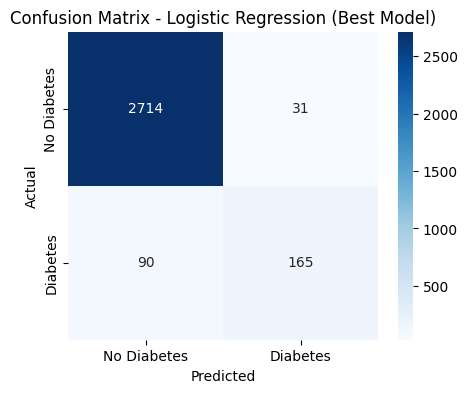

In [25]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Best Model)')
plt.show()

Model Justification



1.   Went with Logistic Regression as the best model since it had the highest F1-score for diabetes (0.73), it balanced precision and recall better than the others
2.   It tied with SVM for the best accuracy (0.96), but Logistic Regression is simpler and trains faster, so it's the more practical pick


1.   Decision Tree and Naive Bayes did catch more actual diabetes cases, but they came with a lot more false alarms, Naive Bayes especially, its precision was only 0.37, so most of the time it flagged someone as diabetic, it was wrong


